In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Read the dataset
df=pd.read_csv('height-weight.csv')
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


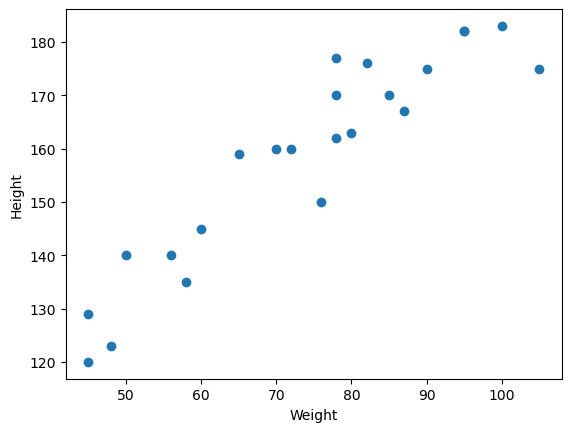

In [4]:
plt.scatter(df.Weight, df.Height)
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

### Problem statement >>  want to predict height based on weight

In [5]:
# Divide the data x and y 
x=df[['Weight']]
y=df[['Height']]

In [6]:
x

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [7]:
y

,Height
0,120
1,135
2,123
3,145
4,160
5,162
6,163
7,175
8,182
9,170


### train test split

In [8]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.25, random_state=1)

In [9]:
x_train

,Weight
10,82
4,70
2,48
18,76
6,80
7,90
1,58
14,85
0,45
15,78


In [10]:
y_test

,Height
20,129
17,159
3,145
13,183
19,167
16,140


In [11]:
y_train

,Height
10,176
4,160
2,123
18,150
6,163
7,175
1,135
14,170
0,120
15,177


In [12]:
y_test

,Height
20,129
17,159
3,145
13,183
19,167
16,140


In [13]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((17, 1), (6, 1), (17, 1), (6, 1))

### Scaling(Optional) >> Strandarization 

In [15]:
from sklearn.preprocessing import StandardScaler

In [18]:
scaler=StandardScaler()
scaler

StandardScaler()

In [19]:
x_train=scaler.fit_transform(x_train) # For train data use fit_transform
x_test=scaler.transform(x_test) # For  data use for transorfm

In [20]:
x_train

array([[ 0.37554243],
       [-0.36825034],
       [-1.73187043],
       [ 0.00364604],
       [ 0.25157697],
       [ 0.87140428],
       [-1.11204312],
       [ 0.56149062],
       [-1.91781863],
       [ 0.12761151],
       [-0.24428488],
       [-1.23600858],
       [ 0.12761151],
       [ 1.18131794],
       [ 1.80114525],
       [ 1.18131794],
       [ 0.12761151]])

In [21]:
x_test

array([[-1.91781863],
       [-0.678164  ],
       [-0.98807766],
       [ 1.49123159],
       [ 0.68545609],
       [-1.60790497]])

In [22]:
# Scaling is optional >> because it doesnot affect the distribution of the data 

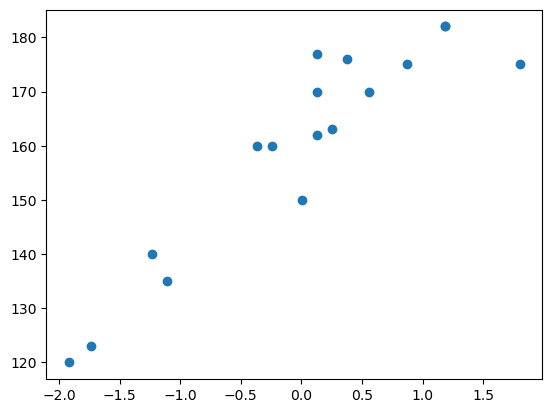

In [23]:
plt.scatter(x_train,y_train)

### Model Train

In [30]:
from sklearn.linear_model import LinearRegression 
# Linear regression parameters
# fit_intersect >> The best fit line will have intercept , by default it is true
# Copy_x >> copy the original x_train and then build the model, it will not modify of the original data
# n_jobs >> -1 means using all processors.
# Positive >> when set to True, forces the coefficients to be positive 

# fit >> train the model
# predict >> test the model
# After building the model, you have attributes of the model
# Coef_
# intercept

In [33]:
regressor=LinearRegression()
regressor

LinearRegression()

In [34]:
regressor.fit(x_train, y_train)

LinearRegression()

In [35]:
regressor.coef_

array([[17.7307072]])

In [36]:
regressor.intercept_

array([160.])

In [38]:
print("The slpoe or coeff of model is ", regressor.coef_)
print("The intercept of the model is ",regressor.intercept_)

The slpoe or coeff of model is  [[17.7307072]]
The intercept of the model is  [160.]


### Prediction on train data 

In [40]:
# prediction on train 
regressor.predict(x_train)

array([[166.65863288],
       [153.47066096],
       [129.29271243],
       [160.06464692],
       [164.46063756],
       [175.45061417],
       [140.28268904],
       [169.95562586],
       [125.99571945],
       [162.26264224],
       [155.66865628],
       [138.08469371],
       [162.26264224],
       [180.94560247],
       [191.93557907],
       [180.94560247],
       [162.26264224]])

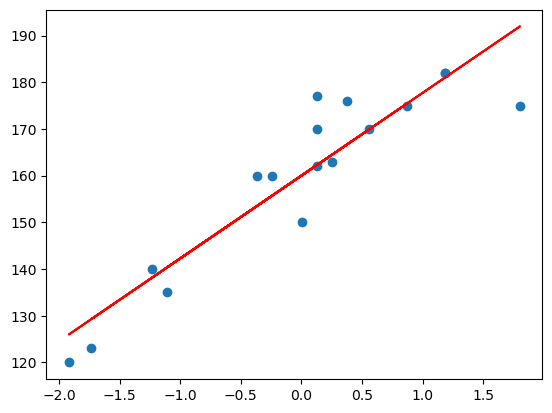

In [43]:
plt.scatter(x_train, y_train)
plt.plot(x_train,regressor.predict(x_train), color='red' )

In [44]:
y_pred_test=regressor.predict(x_test)

In [45]:
y_pred_test

array([[125.99571945],
       [147.97567266],
       [142.48068436],
       [186.44059077],
       [172.15362118],
       [131.49070775]])

In [46]:
y_pred_test, y_test

(array([[125.99571945],
        [147.97567266],
        [142.48068436],
        [186.44059077],
        [172.15362118],
        [131.49070775]]),
     Height
 20     129
 17     159
 3      145
 13     183
 19     167
 16     140)

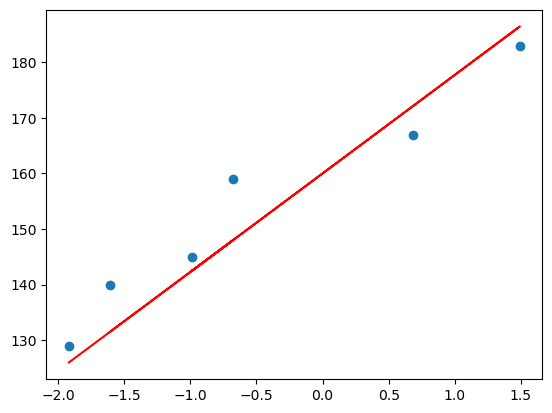

In [48]:
plt.scatter(x_test, y_test)
plt.plot(x_test,regressor.predict(x_test), 'r' )

### Performance Metrics

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [50]:
mean_absolute_error(y_test,y_pred_test)

5.608571289304824

In [51]:
mean_squared_error(y_test,y_pred_test)

41.28566283045539

In [62]:
rsq=r2_score(y_test,y_pred_test)  # rsquare --- 1 - SSR/SST
rsq

0.872103617425661

In [63]:
# Adjusted rsquare
# Adjusted r2  =[1-(1-rsquare)*n-1/(n-k-1)]  # n in no. of observation and k is no. of predictor variable

In [64]:
x_test.shape[1] # [1] for column

1

In [65]:
1-(1-rsq)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)
# Adjusted rsquare will be lesser than r square 

0.8401295217820762

### Assumption

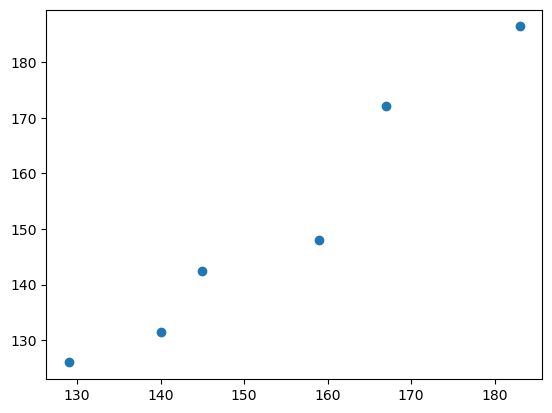

In [67]:
plt.scatter(y_test, y_pred_test)
# To check if y_test and its prediction aligns

In [68]:
#3. error should have constant variation
#4. error should be normally distribution

In [69]:
error=y_test-y_pred_test
error

,Height
20,3.004281
17,11.024327
3,2.519316
13,-3.440591
19,-5.153621
16,8.509292


C:\Users\dell\AppData\Local\Temp\ipykernel_11816\3551057197.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error) # approximately it is normally distribution


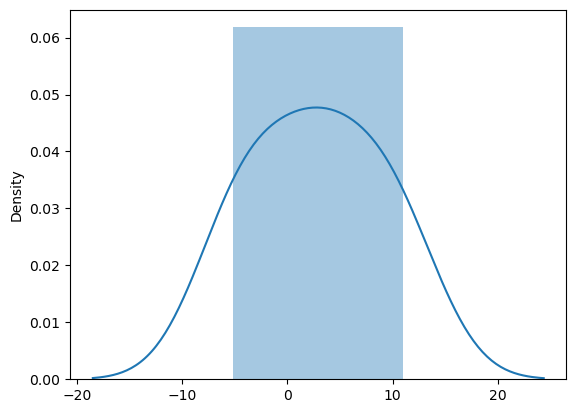

In [72]:
import seaborn as sns
sns.distplot(error) # approximately it is normally distribution 
plt.show()

In [ ]:
# to check constant variance
plt.scatter(error, y_pred_test)